In [1]:
# Import Libraries

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# 2. Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Dataset Configuration


In [ ]:
# Dataset classes
CLASS_NAMES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

CLASS_TO_LABEL = {
    "buildings": 0,
    "forest": 1,
    "glacier": 2,
    "mountain": 3,
    "sea": 4,
    "street": 5
}

print(CLASS_TO_LABEL)

TRAIN_DIR = "/content/drive/MyDrive/Dataset/Intel Image Classification/seg_train/seg_train"
TEST_DIR = "/content/drive/MyDrive/Dataset/Intel Image Classification/seg_test/seg_test"
PRED_DIR = "/content/drive/MyDrive/Dataset/Intel Image Classification/seg_pred/seg_pred"

OUTPUT_DIR = "/content/drive/MyDrive/Dataset/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
METRIC_DIR = os.path.join(OUTPUT_DIR, "metrics")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(METRIC_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

BATCH_SIZE = 32
SEED = 42
VALIDATION_SPLIT = 0.2
NUM_CLASSES = len(CLASS_NAMES)


{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


# 3. Data Understanding, Analysis, Visualization and Cleaning


In [ ]:
def count_images_per_class(directory):
    """
    Count number of images in each class folder.
    """
    data = []

    for class_name in CLASS_NAMES:
        class_path = os.path.join(directory, class_name)

        if os.path.exists(class_path):
            count = len(os.listdir(class_path))
        else:
            count = 0

        data.append({
            "class_name": class_name,
            "label": CLASS_TO_LABEL[class_name],
            "count": count
        })

    return pd.DataFrame(data)


train_distribution = count_images_per_class(TRAIN_DIR)
test_distribution = count_images_per_class(TEST_DIR)

print("Training set distribution:")
display(train_distribution)

print("Test set distribution:")
display(test_distribution)

print("Total training images:", train_distribution["count"].sum())
print("Total test images:", test_distribution["count"].sum())


Training set distribution:


,class_name,label,count
0,buildings,0,2191
1,forest,1,2271
2,glacier,2,2404
3,mountain,3,2512
4,sea,4,2274
5,street,5,2382


Test set distribution:


,class_name,label,count
0,buildings,0,437
1,forest,1,474
2,glacier,2,553
3,mountain,3,525
4,sea,4,510
5,street,5,501


Total training images: 14034
Total test images: 3000


# 4. Plot Class Distribution



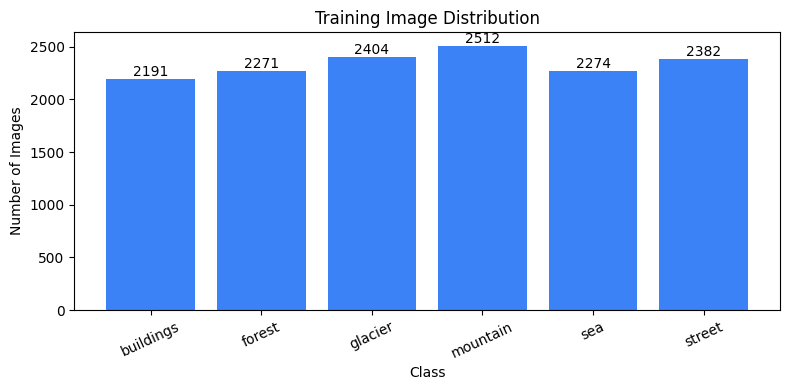

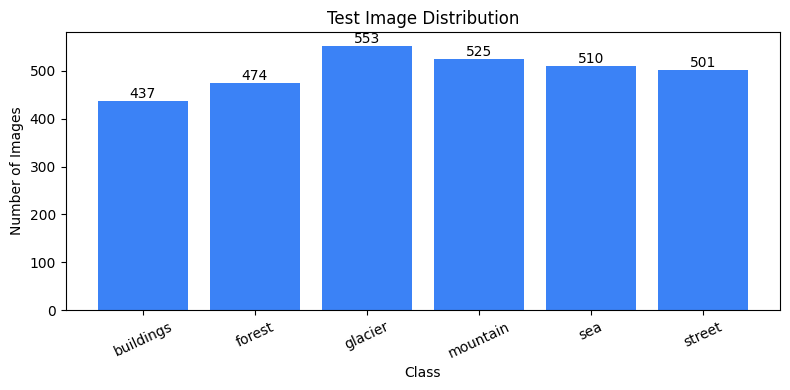

In [ ]:
def plot_class_distribution(distribution, title):
    """
    Plot number of images per class.
    """
    plt.figure(figsize=(8, 4))
    bars = plt.bar(distribution["class_name"], distribution["count"], color="#3B82F6")

    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=25)

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            int(bar.get_height()),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


plot_class_distribution(train_distribution, "Training Image Distribution")
plot_class_distribution(test_distribution, "Test Image Distribution")


# 5. Data Generators and Preprocessing



In [ ]:
def create_generators(image_size=(150, 150), augment=True):
    """
    Create train, validation, and test generators.

    Training data:
    - resized
    - normalized
    - augmented if augment=True

    Validation and test data:
    - resized
    - normalized only
    """

    print("=" * 70)
    print("CREATING DATA GENERATORS")
    print("=" * 70)
    print(f"Image size used       : {image_size[0]} x {image_size[1]}")
    print(f"Batch size            : {BATCH_SIZE}")
    print(f"Validation split      : {VALIDATION_SPLIT * 100:.0f}% of training data")
    print(f"Number of classes     : {len(CLASS_NAMES)}")
    print(f"Class names           : {CLASS_NAMES}")
    print()

    if augment:
        print("Training preprocessing:")
        print("- Rescaling pixel values from 0-255 to 0-1")
        print("- Applying data augmentation:")
        print("  rotation_range=20")
        print("  width_shift_range=0.12")
        print("  height_shift_range=0.12")
        print("  zoom_range=0.15")
        print("  shear_range=0.1")
        print("  horizontal_flip=True")
        print()

        train_datagen = ImageDataGenerator(
            rescale=1.0 / 255.0,
            validation_split=VALIDATION_SPLIT,
            rotation_range=20,
            width_shift_range=0.12,
            height_shift_range=0.12,
            zoom_range=0.15,
            shear_range=0.1,
            horizontal_flip=True,
            fill_mode="nearest"
        )
    else:
        print("Training preprocessing:")
        print("- Rescaling pixel values from 0-255 to 0-1")
        print("- No data augmentation applied")
        print()

        train_datagen = ImageDataGenerator(
            rescale=1.0 / 255.0,
            validation_split=VALIDATION_SPLIT
        )

    print("Validation/Test preprocessing:")
    print("- Rescaling pixel values from 0-255 to 0-1")
    print("- No augmentation is applied to validation or test data")
    print()

    validation_datagen = ImageDataGenerator(
        rescale=1.0 / 255.0,
        validation_split=VALIDATION_SPLIT
    )

    test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

    train_generator = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=image_size,
        batch_size=BATCH_SIZE,
        classes=CLASS_NAMES,
        class_mode="categorical",
        subset="training",
        shuffle=True,
        seed=SEED
    )

    validation_generator = validation_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=image_size,
        batch_size=BATCH_SIZE,
        classes=CLASS_NAMES,
        class_mode="categorical",
        subset="validation",
        shuffle=False,
        seed=SEED
    )

    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=image_size,
        batch_size=BATCH_SIZE,
        classes=CLASS_NAMES,
        class_mode="categorical",
        shuffle=False
    )

    total_train_folder_images = train_generator.samples + validation_generator.samples

    print()
    print("=" * 70)
    print("DATASET SPLIT SUMMARY")
    print("=" * 70)
    print(f"Total images in original training folder : {total_train_folder_images}")
    print(f"Images used for training                 : {train_generator.samples}")
    print(f"Images used for validation               : {validation_generator.samples}")
    print(f"Images used for final testing            : {test_generator.samples}")
    print()
    print(f"Training percentage                      : {(train_generator.samples / total_train_folder_images) * 100:.2f}%")
    print(f"Validation percentage                    : {(validation_generator.samples / total_train_folder_images) * 100:.2f}%")
    print()
    print("Class index mapping:")
    for class_name, class_index in train_generator.class_indices.items():
        print(f"{class_name:10s} -> {class_index}")

    print()
    print("Generator batch information:")
    print(f"Training batches per epoch   : {len(train_generator)}")
    print(f"Validation batches per epoch : {len(validation_generator)}")
    print(f"Test batches                 : {len(test_generator)}")
    print("=" * 70)

    return train_generator, validation_generator, test_generator


In [ ]:
train_gen, val_gen, test_gen = create_generators(
    image_size=(150, 150),
    augment=True
)


CREATING DATA GENERATORS
Image size used       : 150 x 150
Batch size            : 32
Validation split      : 20% of training data
Number of classes     : 6
Class names           : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Training preprocessing:
- Rescaling pixel values from 0-255 to 0-1
- Applying data augmentation:
  rotation_range=20
  width_shift_range=0.12
  height_shift_range=0.12
  zoom_range=0.15
  shear_range=0.1
  horizontal_flip=True

Validation/Test preprocessing:
- Rescaling pixel values from 0-255 to 0-1
- No augmentation is applied to validation or test data

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

DATASET SPLIT SUMMARY
Total images in original training folder : 14034
Images used for training                 : 11230
Images used for validation               : 2804
Images used for final testing            : 3000

Training percentage                      : 80.02%


# 6. Visualize Augmented Images



In [ ]:
def show_augmentations_of_one_image(generator, num_augmented=9):
    """
    Show multiple augmented versions of one image from the training generator.

    Since train_gen already contains augmentation settings, this function
    takes one image from train_gen and repeatedly applies the same generator's
    augmentation pipeline to visualize different transformed versions.
    """

    # Get one batch from the generator
    images, labels = next(generator)

    # Select the first image from the batch
    original_image = images[0]
    class_index = np.argmax(labels[0])
    class_name = CLASS_NAMES[class_index]

    # Convert image back to 0-255 because generator images are already normalized
    original_image_255 = original_image * 255.0

    # Create a temporary augmentation generator using the same augmentation settings
    visualization_datagen = ImageDataGenerator(
        rescale=1.0 / 255.0,
        rotation_range=20,
        width_shift_range=0.12,
        height_shift_range=0.12,
        zoom_range=0.15,
        shear_range=0.1,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    # Add batch dimension so ImageDataGenerator can process it
    image_batch = np.expand_dims(original_image_255, axis=0)

    augmented_iterator = visualization_datagen.flow(
        image_batch,
        batch_size=1,
        shuffle=False
    )

    plt.figure(figsize=(12, 8))

    # Show original image
    plt.subplot(3, 4, 1)
    plt.imshow(original_image)
    plt.title("Original")
    plt.axis("off")

    # Show multiple augmented versions of the same image
    for i in range(num_augmented):
        augmented_image = next(augmented_iterator)[0]

        plt.subplot(3, 4, i + 2)
        plt.imshow(augmented_image)
        plt.title(f"Augmented {i + 1}")
        plt.axis("off")

    plt.suptitle(f"Augmented Versions of One Image: {class_name}")
    plt.tight_layout()
    plt.show()


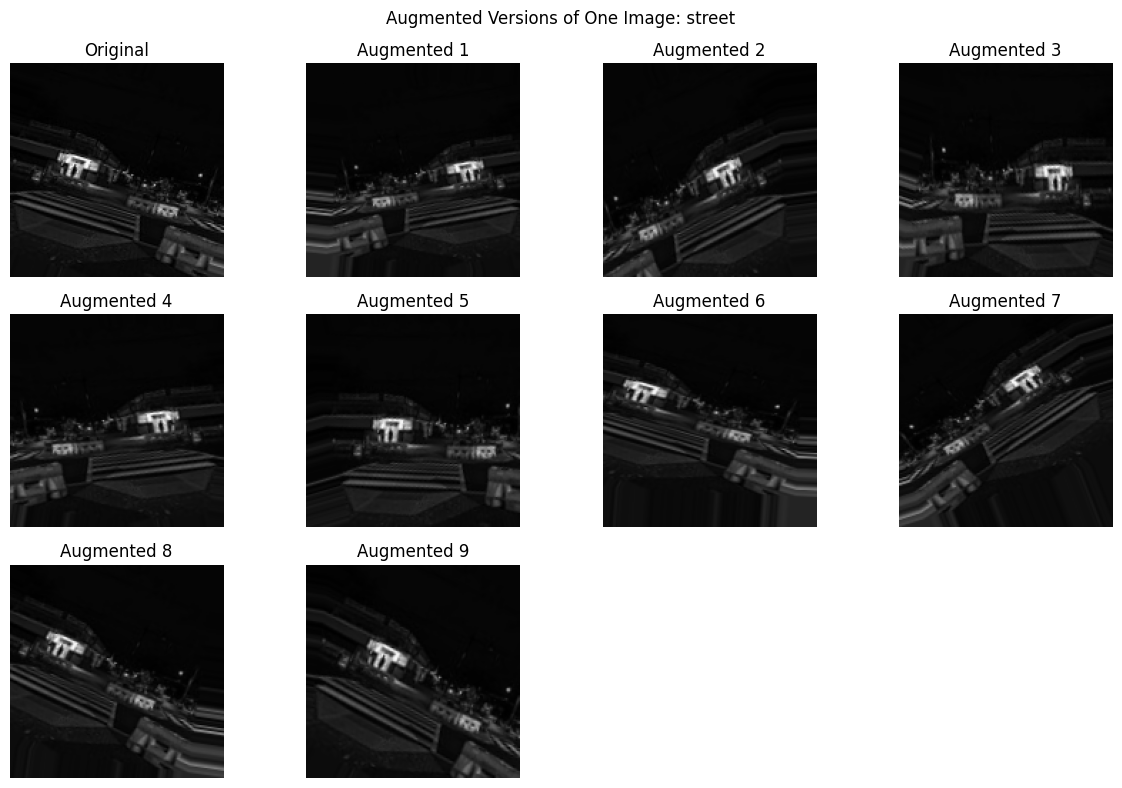

In [ ]:
show_augmentations_of_one_image(train_gen, num_augmented=9)


# Part A: Designing CNN Models from Scratch

## 7. Baseline CNN Model



In [ ]:
def build_baseline_cnn(input_shape=(150, 150, 3), num_classes=6):
    """
    Baseline CNN:
    - 3 convolutional layers
    - each convolution followed by max pooling
    - 3 fully connected layers
    - softmax output layer
    """

    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model


baseline_model = build_baseline_cnn()
baseline_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,751,878 (41.02 MB)

 Trainable params: 10,751,878 (41.02 MB)

 Non-trainable params: 0 (0.00 B)

##8. Compile and Train Baseline Model



In [ ]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

start_time = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

baseline_training_time = time.time() - start_time

print(f"Baseline training time: {baseline_training_time:.2f} seconds")


Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 2541s 7s/step - accuracy: 0.5562 - loss: 1.0995 - val_accuracy: 0.6790 - val_loss: 0.8260
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 760s 2s/step - accuracy: 0.6990 - loss: 0.7993 - val_accuracy: 0.7857 - val_loss: 0.6124
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 749s 2s/step - accuracy: 0.7401 - loss: 0.7035 - val_accuracy: 0.7767 - val_loss: 0.6349
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 826s 2s/step - accuracy: 0.7746 - loss: 0.6198 - val_accuracy: 0.7874 - val_loss: 0.5918
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 813s 2s/step - accuracy: 0.7914 - loss: 0.5744 - val_accuracy: 0.8242 - val_loss: 0.4998
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 763s 2s/step - accuracy: 0.7947 - loss: 0.5648 - val_accuracy: 0.8342 - val_loss: 0.4670
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 824s 2s/step - accuracy: 0.8129 - loss: 0.5234 - val_accuracy: 0.8302 - val_loss: 0.4887
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 768s 2s/step - accuracy: 0.8150 - loss: 0.5100 - val_acc

## 9. Plot Training vs Validation Curves


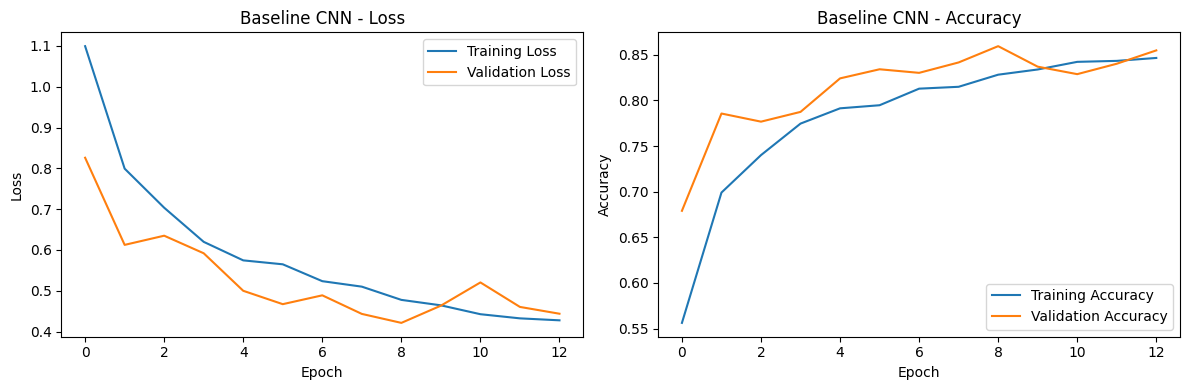

In [ ]:
def plot_training_curves(history, title):
    """
    Plot loss and accuracy curves.
    """
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["loss"], label="Training Loss")
    plt.plot(history_df["val_loss"], label="Validation Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["accuracy"], label="Training Accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_training_curves(baseline_history, "Baseline CNN")


## 10. Evaluation Function


94/94 ━━━━━━━━━━━━━━━━━━━━ 832s 9s/step

Baseline CNN Evaluation
Accuracy: 0.853
Weighted Precision: 0.8532276701733743
Weighted Recall: 0.853
Weighted F1 Score: 0.8528635957452695

Classification Report:
              precision    recall  f1-score   support

   buildings       0.87      0.83      0.85       437
      forest       0.96      0.98      0.97       474
     glacier       0.80      0.81      0.81       553
    mountain       0.78      0.81      0.80       525
         sea       0.85      0.80      0.82       510
      street       0.88      0.89      0.88       501

    accuracy                           0.85      3000
   macro avg       0.86      0.85      0.86      3000
weighted avg       0.85      0.85      0.85      3000



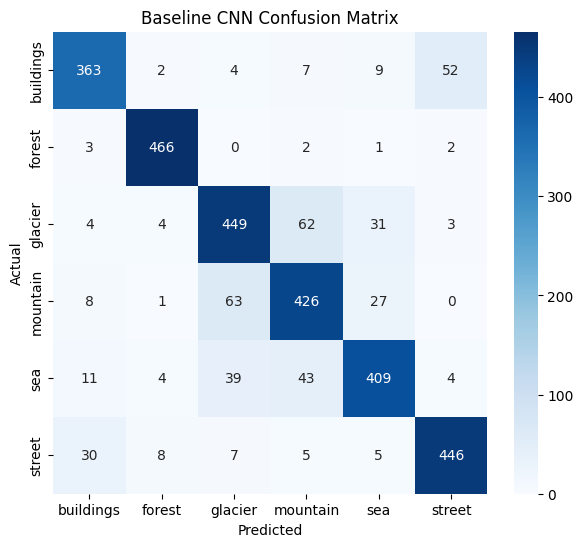

In [ ]:
def evaluate_model(model, generator, model_name):
    """
    Evaluate model using:
    - accuracy
    - precision
    - recall
    - F1 score
    - classification report
    - confusion matrix
    """

    predictions = model.predict(generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    accuracy = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n{model_name} Evaluation")
    print("Accuracy:", accuracy)
    print("Weighted Precision:", precision)
    print("Weighted Recall:", recall)
    print("Weighted F1 Score:", f1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(model_name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


baseline_metrics = evaluate_model(baseline_model, test_gen, "Baseline CNN")
baseline_metrics["training_time"] = baseline_training_time


## 11. Sample Inference Visualization


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step


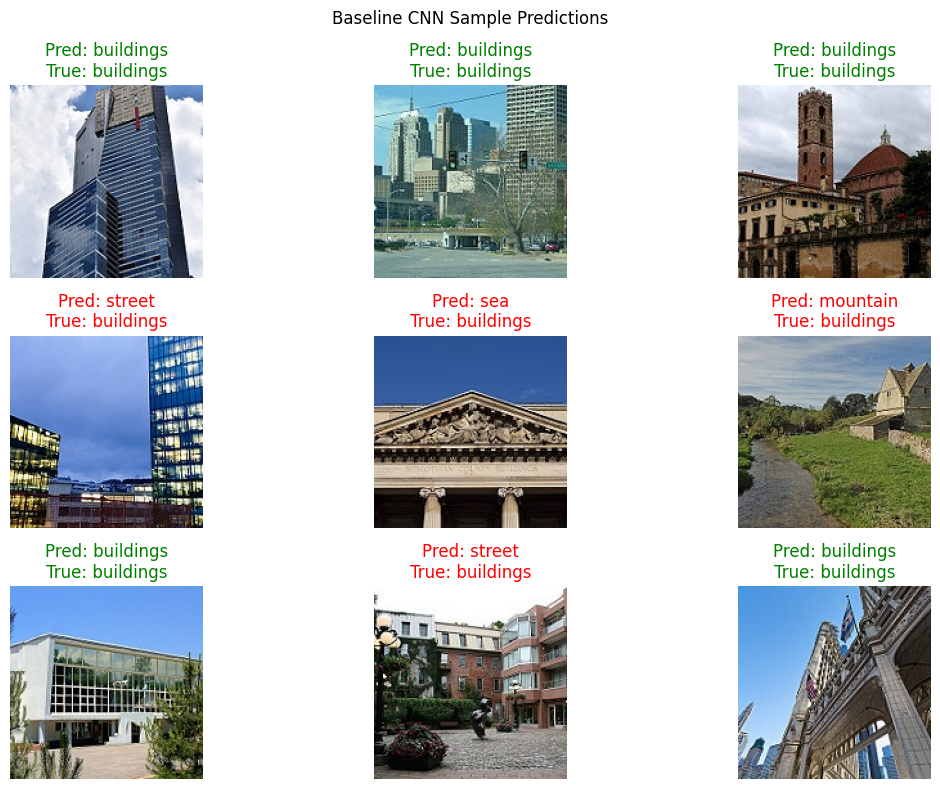

In [ ]:
def plot_sample_predictions(model, generator, title):
    """
    Display sample predictions with true labels.
    """
    images, labels = next(generator)

    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(labels, axis=1)

    plt.figure(figsize=(12, 8))

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])

        pred_label = CLASS_NAMES[predicted_classes[i]]
        true_label = CLASS_NAMES[true_classes[i]]

        color = "green" if pred_label == true_label else "red"

        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_sample_predictions(baseline_model, test_gen, "Baseline CNN Sample Predictions")


## 12. Deeper CNN with Regularization



In [ ]:
def build_deeper_cnn(input_shape=(150, 150, 3), num_classes=6, use_batch_norm=True, use_dropout=True):
    """
    Deeper CNN:
    - 6 convolutional layers
    - batch normalization
    - dropout
    - global average pooling
    """

    inputs = layers.Input(shape=input_shape)
    x = inputs

    for filters in [32, 32, 64, 64, 128, 128]:
        x = layers.Conv2D(filters, kernel_size=(3, 3), padding="same", activation="relu")(x)

        if use_batch_norm:
            x = layers.BatchNormalization()(x)

        if filters in [32, 64, 128]:
            x = layers.MaxPooling2D(pool_size=(2, 2))(x)

            if use_dropout:
                x = layers.Dropout(0.2)(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation="relu")(x)
    if use_dropout:
        x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation="relu")(x)
    if use_dropout:
        x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    return model


deeper_model = build_deeper_cnn()
deeper_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 355,494 (1.36 MB)

 Trainable params: 354,598 (1.35 MB)

 Non-trainable params: 896 (3.50 KB)

## 13. Train Deeper CNN with Adam


In [ ]:
deeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

deeper_training_time = time.time() - start_time

print(f"Deeper CNN Adam training time: {deeper_training_time:.2f} seconds")


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 939s 3s/step - accuracy: 0.5480 - loss: 1.1557 - val_accuracy: 0.4062 - val_loss: 1.8294
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 847s 2s/step - accuracy: 0.6858 - loss: 0.8615 - val_accuracy: 0.6776 - val_loss: 0.8869
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 753s 2s/step - accuracy: 0.7359 - loss: 0.7477 - val_accuracy: 0.5053 - val_loss: 1.9658
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 804s 2s/step - accuracy: 0.7599 - loss: 0.6828 - val_accuracy: 0.7093 - val_loss: 0.8454
Deeper CNN Adam training time: 3343.60 seconds


## 14. Evaluate Deeper CNN



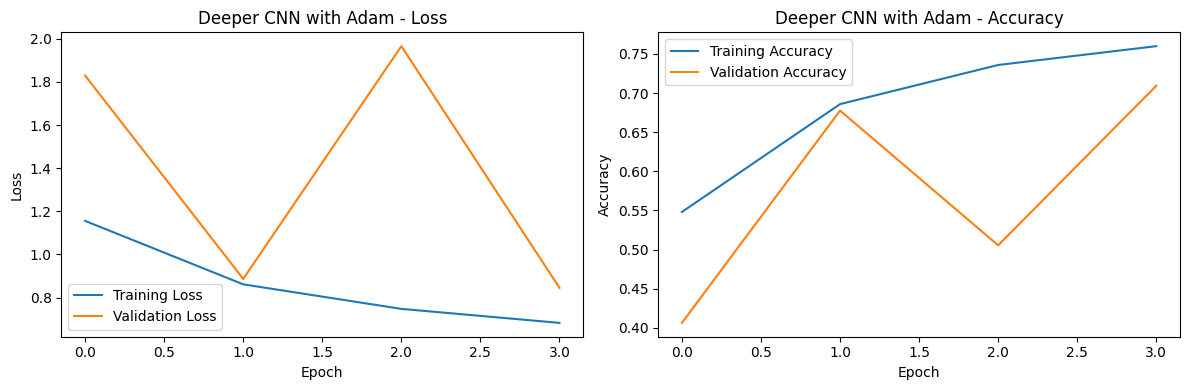

94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 427ms/step

Deeper CNN Adam Evaluation
Accuracy: 0.4266666666666667
Weighted Precision: 0.63852627595093
Weighted Recall: 0.4266666666666667
Weighted F1 Score: 0.3412296641649696

Classification Report:
              precision    recall  f1-score   support

   buildings       1.00      0.00      0.00       437
      forest       0.66      0.87      0.75       474
     glacier       0.47      0.47      0.47       553
    mountain       0.48      0.24      0.32       525
         sea       0.31      0.94      0.47       510
      street       1.00      0.00      0.00       501

    accuracy                           0.43      3000
   macro avg       0.65      0.42      0.34      3000
weighted avg       0.64      0.43      0.34      3000



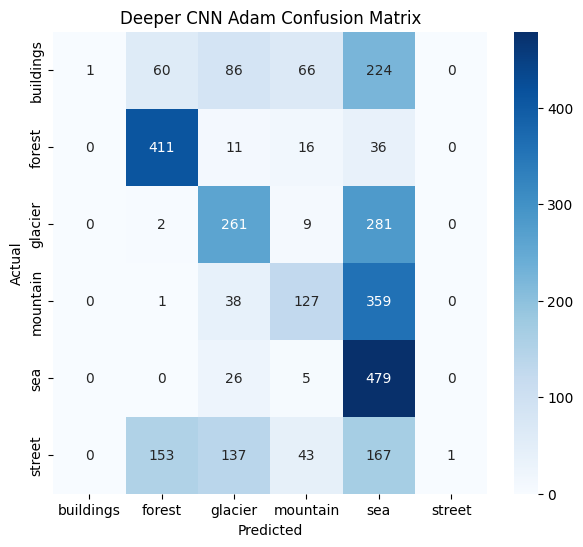

In [ ]:
plot_training_curves(deeper_history, "Deeper CNN with Adam")

deeper_metrics = evaluate_model(deeper_model, test_gen, "Deeper CNN Adam")
deeper_metrics["training_time"] = deeper_training_time


## 15. Optimizer Analysis: Deeper CNN with SGD


In [ ]:
sgd_model = build_deeper_cnn()

sgd_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

sgd_history = sgd_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

sgd_training_time = time.time() - start_time

print(f"Deeper CNN SGD training time: {sgd_training_time:.2f} seconds")


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 755s 2s/step - accuracy: 0.5547 - loss: 1.1341 - val_accuracy: 0.5539 - val_loss: 1.1183
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 803s 2s/step - accuracy: 0.6759 - loss: 0.8729 - val_accuracy: 0.5863 - val_loss: 1.2570
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 763s 2s/step - accuracy: 0.7217 - loss: 0.7793 - val_accuracy: 0.3691 - val_loss: 1.8379
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 753s 2s/step - accuracy: 0.7431 - loss: 0.7305 - val_accuracy: 0.6280 - val_loss: 1.0347
Deeper CNN SGD training time: 3124.06 seconds


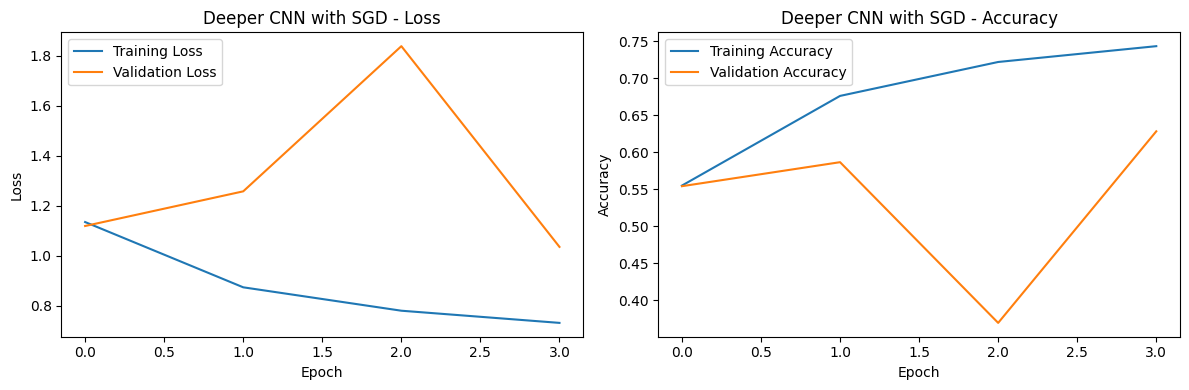

94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 431ms/step

Deeper CNN SGD Evaluation
Accuracy: 0.556
Weighted Precision: 0.6632399064906022
Weighted Recall: 0.556
Weighted F1 Score: 0.5263387385873067

Classification Report:
              precision    recall  f1-score   support

   buildings       0.89      0.17      0.28       437
      forest       0.50      0.98      0.66       474
     glacier       0.74      0.54      0.62       553
    mountain       0.43      0.86      0.57       525
         sea       0.76      0.33      0.46       510
      street       0.69      0.42      0.52       501

    accuracy                           0.56      3000
   macro avg       0.67      0.55      0.52      3000
weighted avg       0.66      0.56      0.53      3000



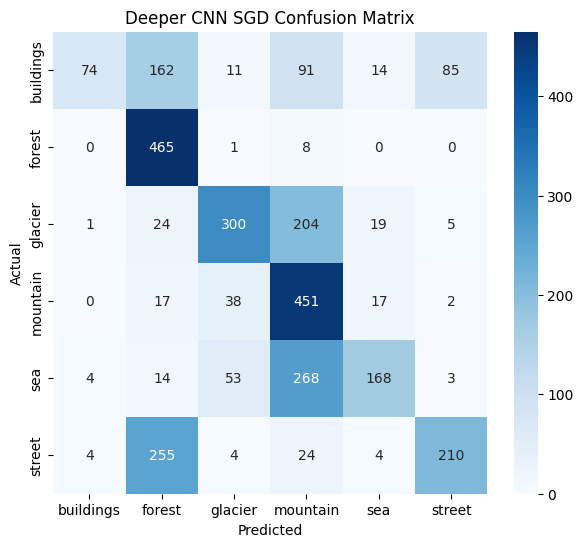

In [ ]:
plot_training_curves(sgd_history, "Deeper CNN with SGD")

sgd_metrics = evaluate_model(sgd_model, test_gen, "Deeper CNN SGD")
sgd_metrics["training_time"] = sgd_training_time


## 16. Ablation Study: Remove Dropout and Batch Normalization


In [ ]:
ablation_model = build_deeper_cnn(
    use_batch_norm=False,
    use_dropout=False
)

ablation_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

ablation_history = ablation_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

ablation_training_time = time.time() - start_time

print(f"Ablation model training time: {ablation_training_time:.2f} seconds")


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 503s 1s/step - accuracy: 0.4878 - loss: 1.2070 - val_accuracy: 0.5724 - val_loss: 1.0230
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 493s 1s/step - accuracy: 0.6291 - loss: 0.9314 - val_accuracy: 0.7079 - val_loss: 0.7662
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - accuracy: 0.7130 - loss: 0.7670 - val_accuracy: 0.7721 - val_loss: 0.6326
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 488s 1s/step - accuracy: 0.7484 - loss: 0.6980 - val_accuracy: 0.7999 - val_loss: 0.5675
Ablation model training time: 1987.19 seconds


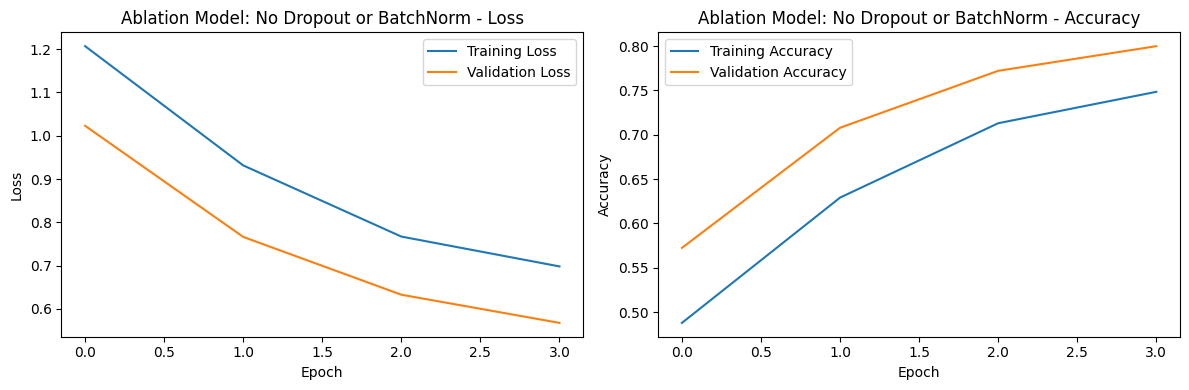

94/94 ━━━━━━━━━━━━━━━━━━━━ 39s 417ms/step

Ablation Model Evaluation
Accuracy: 0.5776666666666667
Weighted Precision: 0.6457123382153092
Weighted Recall: 0.5776666666666667
Weighted F1 Score: 0.5426437300879196

Classification Report:
              precision    recall  f1-score   support

   buildings       0.77      0.43      0.55       437
      forest       0.78      0.91      0.84       474
     glacier       0.78      0.08      0.15       553
    mountain       0.49      0.79      0.61       525
         sea       0.36      0.56      0.44       510
      street       0.70      0.74      0.72       501

    accuracy                           0.58      3000
   macro avg       0.65      0.58      0.55      3000
weighted avg       0.65      0.58      0.54      3000



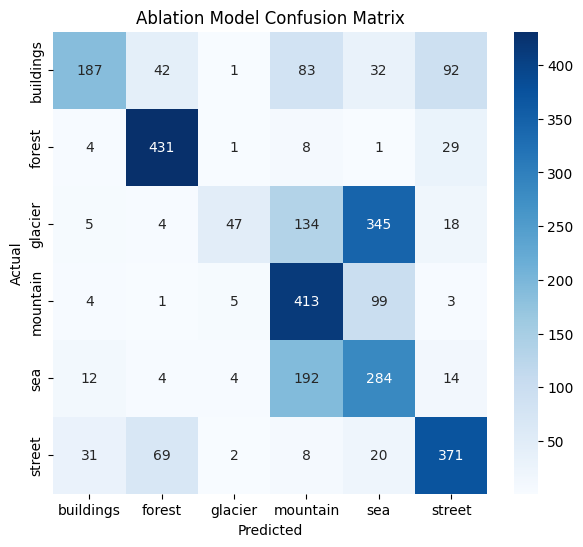

In [ ]:
plot_training_curves(ablation_history, "Ablation Model: No Dropout or BatchNorm")

ablation_metrics = evaluate_model(ablation_model, test_gen, "Ablation Model")
ablation_metrics["training_time"] = ablation_training_time


## 17. Part A Comparative Analysis Table


In [ ]:
part_a_results = pd.DataFrame([
    baseline_metrics,
    deeper_metrics,
    sgd_metrics,
    ablation_metrics
])

display(part_a_results)


,model,accuracy,precision,recall,f1_score,training_time
0,Baseline CNN,0.853000,0.853228,0.853000,0.852864,11719.618278
1,Deeper CNN Adam,0.426667,0.638526,0.426667,0.341230,3343.598812
2,Deeper CNN SGD,0.556000,0.663240,0.556000,0.526339,3124.064356
3,Ablation Model,0.577667,0.645712,0.577667,0.542644,1987.187058


# Part B: Fine-Tuning a Pre-Trained Model



## 18. Create Generators for Transfer Learning


In [ ]:
# MobileNetV2 expects larger input size, commonly 224 x 224
transfer_train_gen, transfer_val_gen, transfer_test_gen = create_generators(
    image_size=(224, 224),
    augment=True
)


CREATING DATA GENERATORS
Image size used       : 224 x 224
Batch size            : 32
Validation split      : 20% of training data
Number of classes     : 6
Class names           : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Training preprocessing:
- Rescaling pixel values from 0-255 to 0-1
- Applying data augmentation:
  rotation_range=20
  width_shift_range=0.12
  height_shift_range=0.12
  zoom_range=0.15
  shear_range=0.1
  horizontal_flip=True

Validation/Test preprocessing:
- Rescaling pixel values from 0-255 to 0-1
- No augmentation is applied to validation or test data

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

DATASET SPLIT SUMMARY
Total images in original training folder : 14034
Images used for training                 : 11230
Images used for validation               : 2804
Images used for final testing            : 3000

Training percentage                      : 80.02%


## 19. Build MobileNetV2 Transfer Learning Model


In [ ]:
def build_transfer_model(input_shape=(224, 224, 3), num_classes=6):
    """
    Transfer learning model using MobileNetV2.

    Steps:
    - Load ImageNet pre-trained convolutional base
    - Remove original ImageNet classifier
    - Add new classifier for 6 scene classes
    """

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )

    # Freeze base model for feature extraction
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    # Images from generator are normalized to 0-1.
    # MobileNetV2 preprocessing expects 0-255 input.
    x = layers.Lambda(
        lambda image: tf.keras.applications.mobilenet_v2.preprocess_input(image * 255.0)
    )(inputs)

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation="relu")(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    return model, base_model


transfer_model, base_model = build_transfer_model()
transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 20. Feature Extraction Training


In [ ]:
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

feature_history = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=8,
    callbacks=callbacks
)

feature_training_time = time.time() - start_time

print(f"Feature extraction training time: {feature_training_time:.2f} seconds")


Epoch 1/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 865s 2s/step - accuracy: 0.8388 - loss: 0.4314 - val_accuracy: 0.8976 - val_loss: 0.2880
Epoch 2/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 812s 2s/step - accuracy: 0.8753 - loss: 0.3280 - val_accuracy: 0.8951 - val_loss: 0.2752
Epoch 3/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 850s 2s/step - accuracy: 0.8833 - loss: 0.3075 - val_accuracy: 0.9023 - val_loss: 0.2662
Epoch 4/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 762s 2s/step - accuracy: 0.8866 - loss: 0.3016 - val_accuracy: 0.9069 - val_loss: 0.2597
Epoch 5/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 917s 2s/step - accuracy: 0.8941 - loss: 0.2782 - val_accuracy: 0.9009 - val_loss: 0.2593
Epoch 6/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 860s 2s/step - accuracy: 0.8962 - loss: 0.2781 - val_accuracy: 0.9058 - val_loss: 0.2599
Epoch 7/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 872s 2s/step - accuracy: 0.9010 - loss: 0.2621 - val_accuracy: 0.9009 - val_loss: 0.2622
Epoch 8/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 847s 2s/step - accuracy: 0.8977 - loss: 0.2607 - val_accuracy: 0.

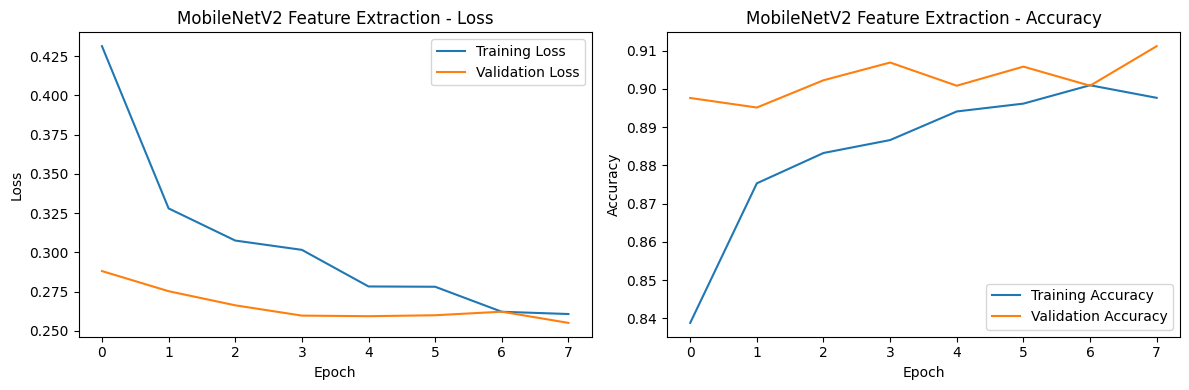

94/94 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step

MobileNetV2 Feature Extraction Evaluation
Accuracy: 0.9153333333333333
Weighted Precision: 0.9162807718768631
Weighted Recall: 0.9153333333333333
Weighted F1 Score: 0.9147993580360962

Classification Report:
              precision    recall  f1-score   support

   buildings       0.95      0.90      0.92       437
      forest       0.99      0.99      0.99       474
     glacier       0.90      0.80      0.84       553
    mountain       0.84      0.89      0.86       525
         sea       0.94      0.97      0.96       510
      street       0.90      0.96      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.91      3000



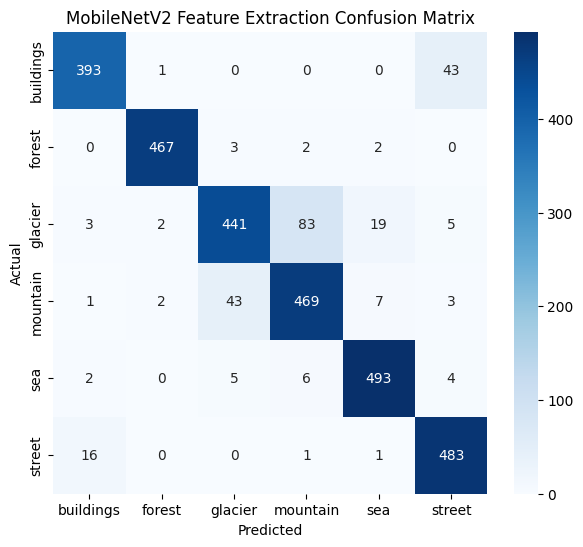

In [ ]:
plot_training_curves(feature_history, "MobileNetV2 Feature Extraction")

feature_metrics = evaluate_model(
    transfer_model,
    transfer_test_gen,
    "MobileNetV2 Feature Extraction"
)

feature_metrics["training_time"] = feature_training_time


## 21. Fine-Tuning the Pre-Trained Model


In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Freeze earlier layers and fine-tune only the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Use a very low learning rate during fine-tuning
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

start_time = time.time()

finetune_history = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=8,
    callbacks=callbacks
)

finetune_training_time = time.time() - start_time

print(f"Fine-tuning training time: {finetune_training_time:.2f} seconds")


Epoch 1/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 1118s 3s/step - accuracy: 0.8405 - loss: 0.4343 - val_accuracy: 0.9137 - val_loss: 0.2487
Epoch 2/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 1096s 3s/step - accuracy: 0.8785 - loss: 0.3276 - val_accuracy: 0.9105 - val_loss: 0.2457
Epoch 3/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 1042s 3s/step - accuracy: 0.8869 - loss: 0.2988 - val_accuracy: 0.9116 - val_loss: 0.2412
Epoch 4/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 1063s 3s/step - accuracy: 0.8996 - loss: 0.2696 - val_accuracy: 0.9130 - val_loss: 0.2379
Epoch 5/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 1059s 3s/step - accuracy: 0.9032 - loss: 0.2605 - val_accuracy: 0.9141 - val_loss: 0.2305
Epoch 6/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 1037s 3s/step - accuracy: 0.9078 - loss: 0.2495 - val_accuracy: 0.9144 - val_loss: 0.2268
Epoch 7/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 1040s 3s/step - accuracy: 0.9146 - loss: 0.2302 - val_accuracy: 0.9169 - val_loss: 0.2236
Epoch 8/8
351/351 ━━━━━━━━━━━━━━━━━━━━ 1095s 3s/step - accuracy: 0.9174 - loss: 0.2288 - val_accu

## 22. Evaluate Fine-Tuned Model


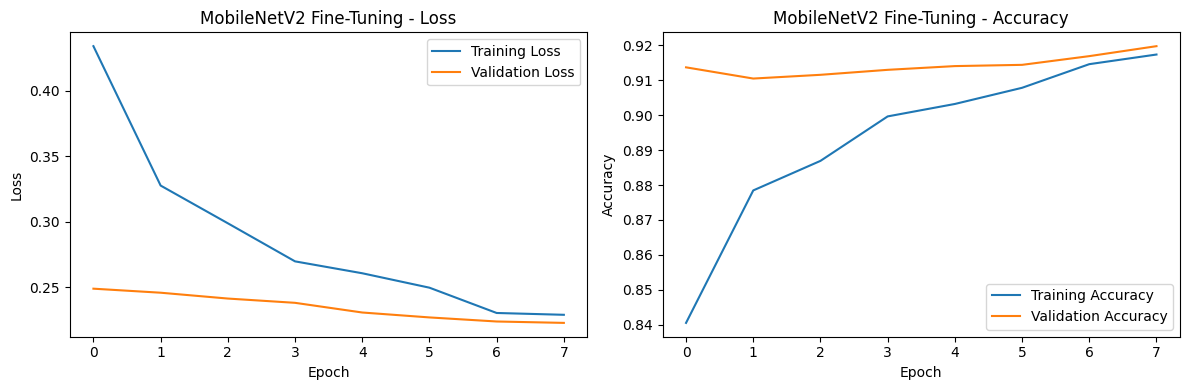

94/94 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step

MobileNetV2 Fine-Tuned Evaluation
Accuracy: 0.9223333333333333
Weighted Precision: 0.9221389912971811
Weighted Recall: 0.9223333333333333
Weighted F1 Score: 0.921744674842703

Classification Report:
              precision    recall  f1-score   support

   buildings       0.95      0.91      0.93       437
      forest       0.99      0.99      0.99       474
     glacier       0.89      0.82      0.86       553
    mountain       0.86      0.87      0.87       525
         sea       0.94      0.98      0.96       510
      street       0.92      0.96      0.94       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



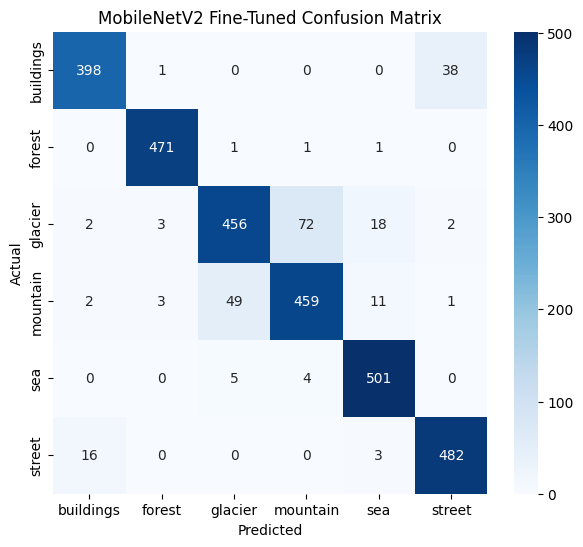

In [ ]:
plot_training_curves(finetune_history, "MobileNetV2 Fine-Tuning")

finetune_metrics = evaluate_model(
    transfer_model,
    transfer_test_gen,
    "MobileNetV2 Fine-Tuned"
)

finetune_metrics["training_time"] = finetune_training_time


## 23. Transfer Learning Sample Predictions


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


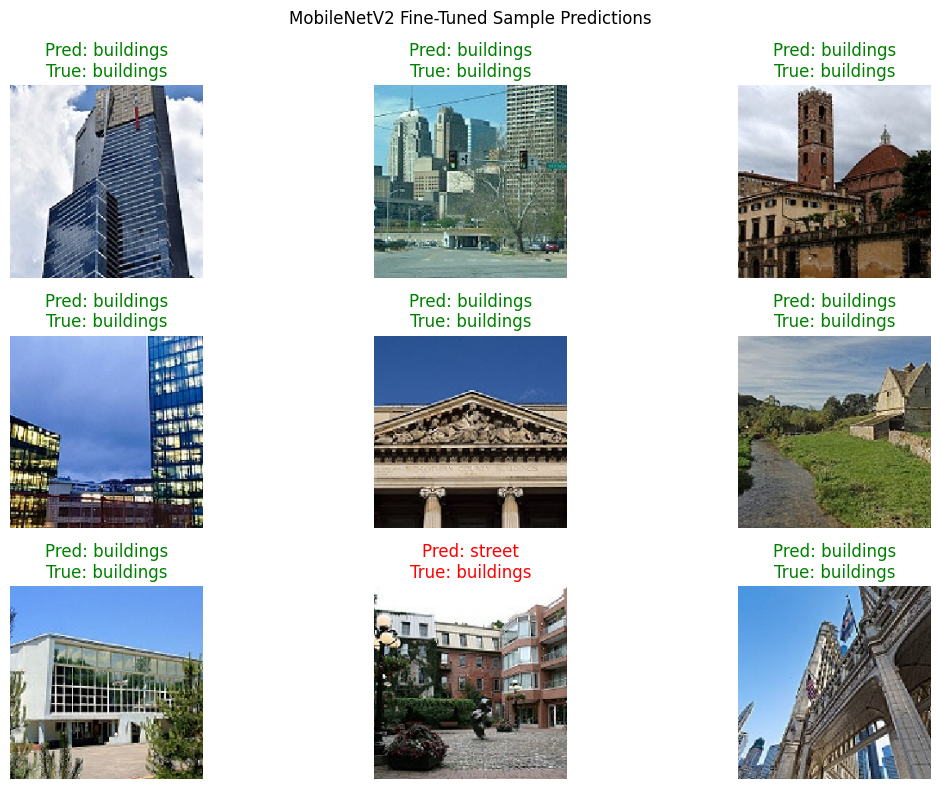

In [ ]:
plot_sample_predictions(
    transfer_model,
    transfer_test_gen,
    "MobileNetV2 Fine-Tuned Sample Predictions"
)


## 24. Final Comparison of All Models


In [ ]:
all_results = pd.DataFrame([
    baseline_metrics,
    deeper_metrics,
    sgd_metrics,
    ablation_metrics,
    feature_metrics,
    finetune_metrics
])

display(all_results)


,model,accuracy,precision,recall,f1_score,training_time
0,Baseline CNN,0.853000,0.853228,0.853000,0.852864,11719.618278
1,Deeper CNN Adam,0.426667,0.638526,0.426667,0.341230,3343.598812
2,Deeper CNN SGD,0.556000,0.663240,0.556000,0.526339,3124.064356
3,Ablation Model,0.577667,0.645712,0.577667,0.542644,1987.187058
4,MobileNetV2 Feature Extraction,0.915333,0.916281,0.915333,0.914799,6786.432153
5,MobileNetV2 Fine-Tuned,0.922333,0.922139,0.922333,0.921745,8549.756335
